<a href="https://colab.research.google.com/github/Pooja-V15/NVIDIA-AI-ML-Internship/blob/main/day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np


In [2]:
inputs = np.array([1, 2, 3])
weights = np.array([0.2, 0.8, -0.5])
bias = 2
output = np.dot(inputs, weights) + bias
print("Neuron Output:", output)

Neuron Output: 2.3


In [3]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = 2

print("Sigmoid Output:", sigmoid(x))

Sigmoid Output: 0.8807970779778823


In [4]:
from sklearn.neural_network import MLPClassifier

# XOR Dataset
X = [[0,0],
     [0,1],
     [1,0],
     [1,1]]

y = [0,1,1,0]

# Neural Network
model = MLPClassifier(hidden_layer_sizes=(4,),
                      max_iter=5000,
                      random_state=42)

model.fit(X, y)

print("Predictions:")
print(model.predict(X))

Predictions:
[0 0 0 0]


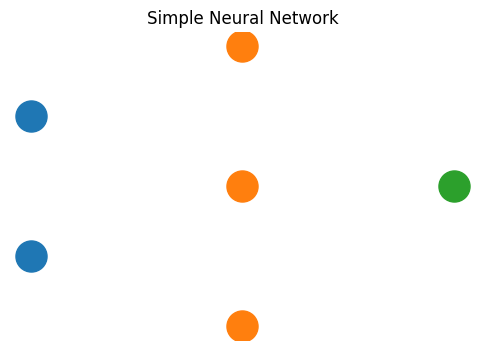

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# Input Layer
plt.scatter([1,1],[1,2],s=500)

# Hidden Layer
plt.scatter([3,3,3],[0.5,1.5,2.5],s=500)

# Output Layer
plt.scatter([5],[1.5],s=500)

plt.title("Simple Neural Network")
plt.axis('off')
plt.show()


In [6]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.20.0
GPU Available: []


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Load Fashion-MNIST Dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# Normalize Pixel Values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model on GPU
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", test_accuracy)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_classes))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_classes))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7775 - loss: 0.6228 - val_accuracy: 0.8497 - val_loss: 0.4210
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8447 - loss: 0.4247 - val_accuracy: 0.8671 - val_loss: 0.3652
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8584 - loss: 0.3841 - val_accuracy: 0.8685 - val_loss: 0.3626
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8694 - loss: 0.3571 - val_accuracy: 0.8787 - val_loss: 0.3367
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8729 - loss: 0.3419 - val_accuracy: 0.8764 - val_loss: 0.3331
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8785 - loss: 0.3255 - val_accuracy: 0.8761 - val_loss: 0.3411
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8861 - loss: 0.3112 - val_accuracy: 0.8831 - val_loss: 0.3250
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8871 - loss: 0.3020 - val_accuracy: 0

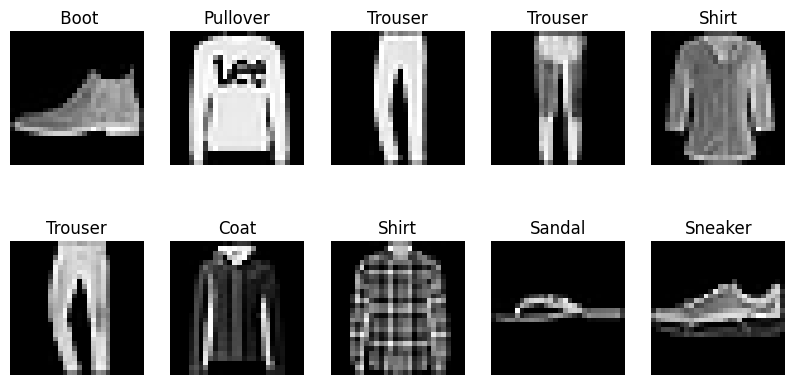

In [9]:
class_names = [
    'T-shirt','Trouser','Pullover','Dress',
    'Coat','Sandal','Shirt','Sneaker',
    'Bag',' Boot'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(class_names[y_pred_classes[i]])
    plt.axis('off')

plt.show()